In [1]:
import pandas as pd
import os

BASE_PATH = os.path.join("..", "data", "Dataset_T-ITS.csv")

In [2]:
df_data = pd.read_csv(BASE_PATH, sep=",", low_memory=False)

In [3]:
print(df_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 54783 entries, 0 to 54782
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   timestamp_c             54783 non-null  str  
 1   frame.number            54783 non-null  str  
 2   frame.len               54783 non-null  str  
 3   frame.protocols         54783 non-null  str  
 4   wlan.duration           54783 non-null  str  
 5   wlan.ra                 54783 non-null  str  
 6   wlan.ta                 54783 non-null  str  
 7   wlan.da                 54783 non-null  str  
 8   wlan.sa                 54783 non-null  str  
 9   wlan.bssid              54783 non-null  str  
 10  wlan.frag               54783 non-null  str  
 11  wlan.seq                54783 non-null  str  
 12  llc.type                54783 non-null  str  
 13  ip.hdr_len              54783 non-null  str  
 14  ip.len                  54783 non-null  str  
 15  ip.id                   54783 

In [4]:
print(df_data["class"].value_counts())

class
Replay        12006
DoS attack    11671
benign         9425
class             2
Name: count, dtype: int64


In [5]:
# Convertendo as colunas de tamanho para numérico
cols_tamanho = ['frame.len', 'ip.len', 'data.len']
for col in cols_tamanho:
    df_data[col] = pd.to_numeric(df_data[col], errors='coerce')

# Removendo possíveis NaNs gerados na conversão
df_clean = df_data.dropna(subset=cols_tamanho + ['class'])

In [6]:
analise_estatistica = df_clean.groupby('class')[cols_tamanho].agg(['mean', 'std', 'max', 'min'])
analise_estatistica

frame.len                             ip.len                    \
                  mean        std    max   min       mean        std    max   
class                                                                         
DoS attack   44.231771  51.334134  334.0  24.0  15.653414  48.794597  302.0   
Replay       49.202899  57.531319  334.0  24.0  20.173080  54.732501  302.0   
benign      127.104509  94.262158  334.0  24.0  92.005942  93.926543  302.0   

                  data.len                         
            min       mean        std    max  min  
class                                              
DoS attack  0.0   9.844829  39.279531  179.0  0.0  
Replay      0.0  13.782442  46.129085  182.0  0.0  
benign      0.0  74.061114  83.864633  181.0  0.0

### Inspeção direcionada: **Replay** vs **DoS attack**

O modelo LSTM usa só `frame.len`, `ip.len` e `time_since_last_packet`. Abaixo comparamos as **demais** colunas da pilha (**TCP/UDP, WLAN, data, LLC** e alguns campos **IP**), para ver **o que os dois ataques têm em comum** e onde há **diferença** (candidatas a novas *features*).

*Nota:* muitas colunas têm **muitos `NaN`** em frames sem essa camada — as taxas de preenchimento aparecem por classe.

Linhas Replay+DoS: 23677 | Colunas candidatas à inspeção: 30


classe,DoS attack,Replay,diff_Replay_menos_DoS
coluna,,,
data.data,100.0,100.0,0.0
data.len,100.0,100.0,0.0
wlan.seq,100.0,100.0,0.0
wlan.sa,100.0,100.0,0.0
wlan.ra,100.0,100.0,0.0
wlan.frag,100.0,100.0,0.0
wlan.fc.type,100.0,100.0,0.0
wlan.fc.subtype,100.0,100.0,0.0
wlan.duration,100.0,100.0,0.0



=== data.data (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=145
data.data
0     10866
16       28
1        26
12       23
29       22 

  DoS attack: n_validos=11671 | nunique=133
data.data
0      10824
65        39
115       38
61        28
45        26 


=== frame.protocols (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=6
frame.protocols
0    10001
3     1046
2      898
1       52
4        7 

  DoS attack: n_validos=11671 | nunique=6
frame.protocols
0    10036
3      847
2      682
1       76
4       28 


=== tcp.options (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=2
tcp.options
0    11188
1      818 

  DoS attack: n_validos=11671 | nunique=2
tcp.options
0    10989
1      682 


=== wlan.bssid (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=1
wlan.bssid
0    12006 

  DoS attack: n_validos=11671 | nunique=1
wlan.bssid
0    11671 


=== wlan.da (top 5 por classe) ===
  Replay: n_validos=12006 | nunique=7
wlan.da
1    6840
0    461

,count,mean,std,median,min,max
class,,,,,,
DoS attack,11671,1.077371,0.302961,1.0,1,3
Replay,12006,1.094286,0.327965,1.0,1,3



=== Estatísticas numéricas Replay vs DoS (colunas com ≥50 valores por classe) ===


,mean_Replay,mean_DoS,std_Replay,std_DoS,median_Replay,median_DoS,mannwhitney_p,sig_5pct
coluna,,,,,,,,
wlan.fc.type,7.687823e-01,3.514695e-01,9.729426e-01,7.612212e-01,0.0,0.0,5.734683e-279,True
wlan.seq,1.272489e+03,1.617667e+03,1.298674e+03,1.249948e+03,771.0,1320.0,8.240472e-158,True
wlan.duration,2.403251e+02,2.736164e+02,1.085572e+02,9.613449e+01,314.0,314.0,9.633540e-158,True
ip.proto,2.035732e+00,1.628052e+00,5.095945e+00,4.601240e+00,0.0,0.0,3.621001e-11,True
ip.id,3.333612e+03,2.952480e+03,1.293157e+04,1.188945e+04,0.0,0.0,4.221906e-11,True
ip.ttl,3.261169e+01,2.644546e+01,7.801810e+01,7.120159e+01,0.0,0.0,5.466972e-11,True
data.len,1.378244e+01,9.844829e+00,4.612909e+01,3.927953e+01,0.0,0.0,5.606586e-11,True
ip.hdr_len,3.276695e+00,2.671579e+00,7.402819e+00,6.804279e+00,0.0,0.0,6.246351e-11,True
udp.length,1.471614e+01,1.111190e+01,4.873219e+01,4.324212e+01,0.0,0.0,2.747797e-09,True


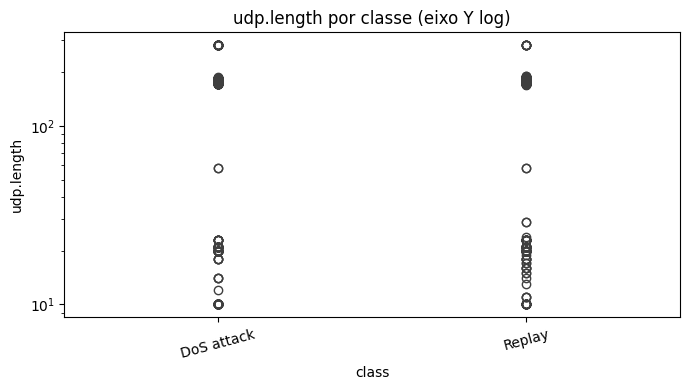

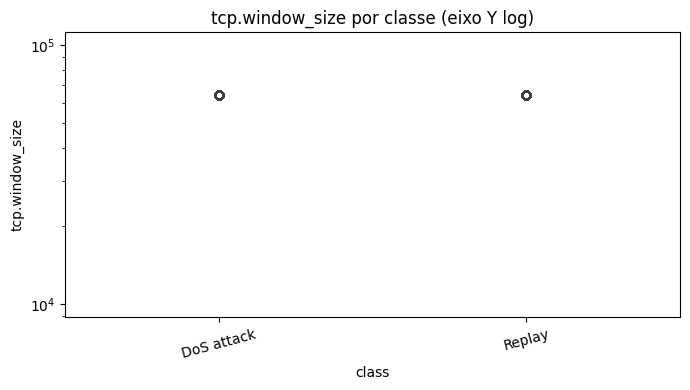

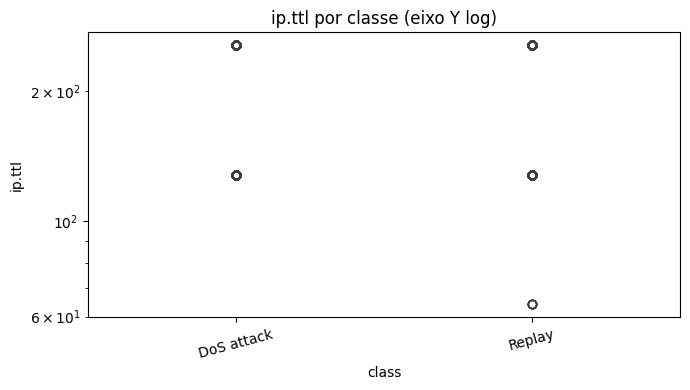

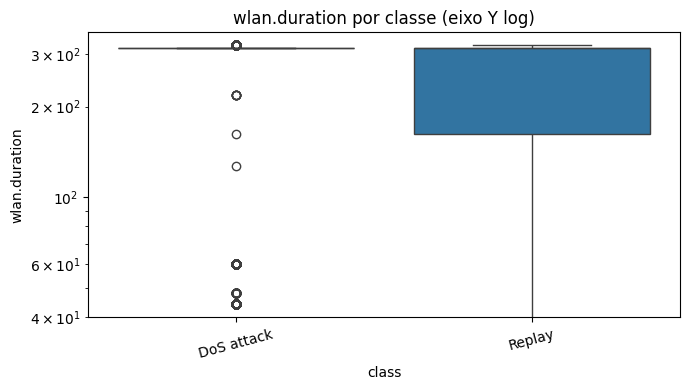

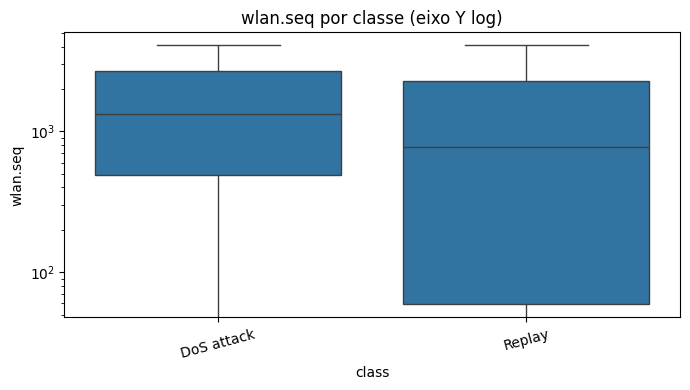

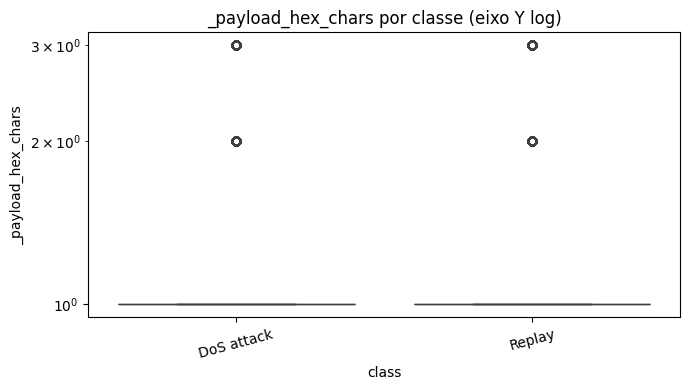

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

FEATS_MODELO = {"frame.len", "ip.len", "time_since_last_packet"}
EXTRAS_IP = {"ip.ttl", "ip.proto", "ip.flags", "ip.id", "ip.hdr_len", "frame.protocols"}
PREFIXOS = ("tcp.", "udp.", "wlan.", "data.", "llc.")

def colunas_inspecao(df):
    out = []
    for c in df.columns:
        if c in ("class", "timestamp_c") or c in FEATS_MODELO:
            continue
        if c.startswith(PREFIXOS) or c in EXTRAS_IP:
            out.append(c)
    return out

COLS_INSP = colunas_inspecao(df_clean)
rd = df_clean[df_clean["class"].isin(["Replay", "DoS attack"])].copy()
print(f"Linhas Replay+DoS: {len(rd)} | Colunas candidatas à inspeção: {len(COLS_INSP)}")

# --- 1) Taxa de não-nulo por classe (qualidade / cobertura) ---
linhas = []
for col in COLS_INSP:
    for lab in ("Replay", "DoS attack"):
        m = rd.loc[rd["class"] == lab, col].notna().mean()
        linhas.append({"coluna": col, "classe": lab, "pct_nao_nulo": round(100 * m, 2)})
cobertura = pd.DataFrame(linhas).pivot(index="coluna", columns="classe", values="pct_nao_nulo")
cobertura["diff_Replay_menos_DoS"] = cobertura["Replay"] - cobertura["DoS attack"]
cobertura = cobertura.assign(_abs_diff=cobertura["diff_Replay_menos_DoS"].abs()).sort_values("_abs_diff", ascending=False).drop(columns="_abs_diff")
display(cobertura)

# --- 2) Colunas tratadas como string (endereços, payload bruto, protocolos) ---
STRING_LIKE = {
    "wlan.ra", "wlan.ta", "wlan.da", "wlan.sa", "wlan.bssid",
    "ip.src", "ip.dst", "data.data", "tcp.options", "frame.protocols",
}

def resumo_categorico(col, top_n=5):
    print(f"\n=== {col} (top {top_n} por classe) ===")
    for lab in ("Replay", "DoS attack"):
        sub = rd.loc[rd["class"] == lab, col].dropna()
        vc = sub.astype(str).value_counts().head(top_n)
        print(f"  {lab}: n_validos={len(sub)} | nunique={sub.nunique()}")
        print(vc.to_string(), "\n")

for c in sorted(STRING_LIKE & set(COLS_INSP)):
    if c in rd.columns:
        resumo_categorico(c, top_n=5)

# Tamanho do hex em data.data (proxy de payload sem decodificar MAVLink)
if "data.data" in rd.columns:
    rd["_payload_hex_chars"] = rd["data.data"].apply(lambda x: len(x) if isinstance(x, str) else np.nan)
    print("\n=== _payload_hex_chars (Replay vs DoS) ===")
    display(
        rd.groupby("class")["_payload_hex_chars"].agg(["count", "mean", "std", "median", "min", "max"])
    )

# --- 3) Colunas numéricas (coerção) ---
num_candidates = [c for c in COLS_INSP if c not in STRING_LIKE]
for c in num_candidates:
    rd[c] = pd.to_numeric(rd[c], errors="coerce")

stats_rows = []
pvalue_rows = []
for col in num_candidates:
    a = rd.loc[rd["class"] == "Replay", col].dropna()
    b = rd.loc[rd["class"] == "DoS attack", col].dropna()
    if len(a) < 50 or len(b) < 50:
        continue
    stats_rows.append({
        "coluna": col,
        "mean_Replay": a.mean(),
        "mean_DoS": b.mean(),
        "std_Replay": a.std(),
        "std_DoS": b.std(),
        "median_Replay": a.median(),
        "median_DoS": b.median(),
    })
    # Teste não-paramétrico (distribuições não normais, caudas pesadas)
    try:
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        pvalue_rows.append({"coluna": col, "mannwhitney_p": p})
    except ValueError:
        pass

tab_stats = pd.DataFrame(stats_rows).set_index("coluna")
tab_p = pd.DataFrame(pvalue_rows).set_index("coluna")
if len(tab_p):
    tab_stats = tab_stats.join(tab_p)
    tab_stats["sig_5pct"] = tab_stats["mannwhitney_p"] < 0.05
print("\n=== Estatísticas numéricas Replay vs DoS (colunas com ≥50 valores por classe) ===")
display(tab_stats.sort_values("mannwhitney_p") if "mannwhitney_p" in tab_stats.columns else tab_stats)

# --- 4) Boxplots (escala log) para colunas com boa cobertura e diferença visual ---
plot_cols = [c for c in ["udp.length", "tcp.window_size", "ip.ttl", "wlan.duration", "wlan.seq", "_payload_hex_chars"] if c in rd.columns]
plot_cols = [c for c in plot_cols if rd[c].notna().sum() > 200]
for col in plot_cols:
    sub = rd[["class", col]].dropna()
    if sub["class"].nunique() < 2:
        continue
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=sub, x="class", y=col)
    plt.yscale("log")
    plt.title(f"{col} por classe (eixo Y log)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [8]:
# Certifique-se de que a coluna de tempo é numérica
df_data['time_since_last_packet'] = pd.to_numeric(df_data['time_since_last_packet'], errors='coerce')

# Análise estatística do intervalo de tempo
analise_temporal = df_data.groupby('class')['time_since_last_packet'].agg(['mean', 'std', 'min', 'max'])
print(analise_temporal)

                mean       std  min        max
class                                         
DoS attack  0.051417  0.441322  0.0  27.724660
Replay      0.085303  0.399871  0.0  17.089158
benign      0.434762  1.201406  0.0  28.844855
class            NaN       NaN  NaN        NaN


In [9]:
from sklearn.preprocessing import MinMaxScaler

# Selecionando as colunas que decidimos ser as mais importantes (Features)
features = ['frame.len', 'ip.len', 'time_since_last_packet']
scaler = MinMaxScaler()

# Aplicando a normalização
df_clean[features] = scaler.fit_transform(df_clean[features])

In [10]:
import numpy as np

def preparar_sequencias(data, target, window_size=10):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# Transformando as classes em números para o 'target'
# benign -> 0, DoS -> 1, Replay -> 2
target = df_clean['class'].map({'benign': 0, 'DoS attack': 1, 'Replay': 2}).values
data = df_clean[features].values

# Criando as janelas
window = 10 
X, y = preparar_sequencias(data, target, window)

print(f"Formato dos dados para a LSTM: {X.shape}") 
# O resultado será (Amostras, 10, 3) -> 10 pacotes, 3 características cada.

Formato dos dados para a LSTM: (33092, 10, 3)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (26473, 10, 3), Teste: (6619, 10, 3)


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    # Nova forma recomendada: Definir a entrada primeiro
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # Camada LSTM: 50 unidades
    LSTM(50, return_sequences=False),
    
    # Dropout para evitar Overfitting
    Dropout(0.2),
    
    # Camada densa final
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,953 (42.79 KB)

 Trainable params: 10,953 (42.79 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=20,           # Quantas vezes a rede verá todo o dataset
    batch_size=32,       # Quantos exemplos ela processa por vez
    validation_split=0.1 # Reserva um pouco dos dados de treino para validar durante o processo
)

Epoch 1/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5883 - loss: 0.7960 - val_accuracy: 0.6057 - val_loss: 0.7617
Epoch 2/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6163 - loss: 0.7438 - val_accuracy: 0.6182 - val_loss: 0.7430
Epoch 3/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6228 - loss: 0.7307 - val_accuracy: 0.6314 - val_loss: 0.7351
Epoch 4/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6233 - loss: 0.7239 - val_accuracy: 0.6288 - val_loss: 0.7239
Epoch 5/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6292 - loss: 0.7164 - val_accuracy: 0.6341 - val_loss: 0.7258
Epoch 6/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6352 - loss: 0.7108 - val_accuracy: 0.6397 - val_loss: 0.7145
Epoch 7/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6338 - loss: 0.7034 - val_accuracy: 0.6435 - val_loss: 0.7069
Epoch 8/20
745/745 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6421 - loss: 0.6941 - val_accuracy: 0.

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step
              precision    recall  f1-score   support

      Benign       0.84      0.90      0.87      1883
  DoS attack       0.53      0.89      0.67      2334
      Replay       0.77      0.23      0.36      2402

    accuracy                           0.65      6619
   macro avg       0.72      0.67      0.63      6619
weighted avg       0.71      0.65      0.61      6619



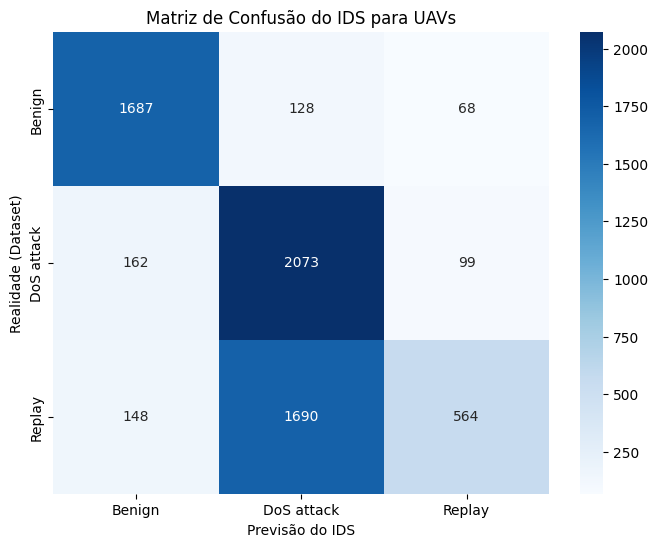

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Fazer as previsões
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Gerar o relatório de classificação
# Lembre-se da ordem: 0: benign, 1: DoS attack, 2: Replay (ajuste se a sua ordem for outra)
print(classification_report(y_test, y_pred_classes, target_names=['Benign', 'DoS attack', 'Replay']))

# 3. Gerar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'DoS attack', 'Replay'],
            yticklabels=['Benign', 'DoS attack', 'Replay'])
plt.xlabel('Previsão do IDS')
plt.ylabel('Realidade (Dataset)')
plt.title('Matriz de Confusão do IDS para UAVs')
plt.show()